In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
%matplotlib inline

In [2]:
# Dataset XOR

X = np.array([[0., 0.],
              [0., 1.],
              [1., 0.],
              [1., 1.]])
y = np.array([[0.],
              [1.],
              [1.],
              [0.]])

print("X:", X.shape, "y:", y.shape)
for xi, yi in zip(X, y):
    print(f"  {xi} -> {yi[0]}")

X: (4, 2) y: (4, 1)
  [0. 0.] -> 0.0
  [0. 1.] -> 1.0
  [1. 0.] -> 1.0
  [1. 1.] -> 0.0


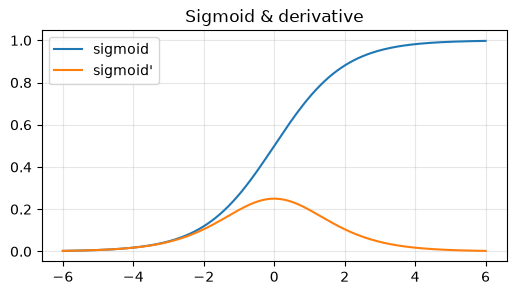

In [3]:
# activations
def sigmoid(z):
    z = np.clip(z, -500, 500)  # numerical stability
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1.0 - s)

# quick sanity plot
zs = np.linspace(-6, 6, 200)
plt.figure(figsize=(6, 3))
plt.plot(zs, sigmoid(zs), label="sigmoid")
plt.plot(zs, sigmoid_prime(zs), label="sigmoid'")
plt.legend(); plt.grid(True, alpha=0.3); plt.title("Sigmoid & derivative")
plt.show()

In [4]:
# Architecture and Init
input_size, hidden_size, output_size = 2, 4, 1

W1 = np.random.randn(input_size, hidden_size) * 0.5
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.5
b2 = np.zeros((1, output_size))

print("W1", W1.shape, "W2", W2.shape)

W1 (2, 4) W2 (4, 1)


In [5]:
# forward pass
def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    return z1, a1, z2, a2

z1, a1, z2, preds = forward(X, W1, b1, W2, b2)
print("raw predictions:\n", preds.ravel())

raw predictions:
 [0.44669943 0.43029337 0.42699871 0.41263144]


In [6]:
# Loss (MSE)
def mse_loss(pred, target):
    return np.mean((pred - target) ** 2)

print("initial loss:", mse_loss(preds, y))

initial loss: 0.2556753002334093


In [7]:
# Back propagation (chain rule)
def backward(X, y, z1, a1, z2, a2, W2):
    m = X.shape[0]
    # dL/da2 for MSE = 2(a2 - y); chain with sigmoid'
    dz2 = 2.0 * (a2 - y) * sigmoid_prime(z2)
    dW2 = (a1.T @ dz2) / m
    db2 = np.mean(dz2, axis=0, keepdims=True)

    dz1 = (dz2 @ W2.T) * sigmoid_prime(z1)
    dW1 = (X.T @ dz1) / m
    db1 = np.mean(dz1, axis=0, keepdims=True)
    return dW1, db1, dW2, db2

In [8]:
# Training Loop
def train(X, y, epochs=2000, lr=1.0):
    np.random.seed(42)
    W1 = np.random.randn(2, 4) * 0.5
    b1 = np.zeros((1, 4))
    W2 = np.random.randn(4, 1) * 0.5
    b2 = np.zeros((1, 1))
    history = []

    for epoch in range(epochs):
        z1, a1, z2, a2 = forward(X, W1, b1, W2, b2)
        loss = mse_loss(a2, y)
        history.append(loss)
        dW1, db1, dW2, db2 = backward(X, y, z1, a1, z2, a2, W2)
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
        if epoch % 200 == 0:
            print(f"epoch {epoch:4d}  loss={loss:.6f}")

    return (W1, b1, W2, b2), history

params, history = train(X, y)
W1, b1, W2, b2 = params

epoch    0  loss=0.255675
epoch  200  loss=0.250022
epoch  400  loss=0.249831
epoch  600  loss=0.249275
epoch  800  loss=0.243961
epoch 1000  loss=0.203313
epoch 1200  loss=0.125944
epoch 1400  loss=0.040592
epoch 1600  loss=0.014727
epoch 1800  loss=0.007935


In [9]:
# Evaluate and Plot
def train(X, y, epochs=2000, lr=1.0):
    np.random.seed(42)
    W1 = np.random.randn(2, 4) * 0.5
    b1 = np.zeros((1, 4))
    W2 = np.random.randn(4, 1) * 0.5
    b2 = np.zeros((1, 1))
    history = []

    for epoch in range(epochs):
        z1, a1, z2, a2 = forward(X, W1, b1, W2, b2)
        loss = mse_loss(a2, y)
        history.append(loss)
        dW1, db1, dW2, db2 = backward(X, y, z1, a1, z2, a2, W2)
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
        if epoch % 200 == 0:
            print(f"epoch {epoch:4d}  loss={loss:.6f}")

    return (W1, b1, W2, b2), history

params, history = train(X, y)
W1, b1, W2, b2 = params

epoch    0  loss=0.255675
epoch  200  loss=0.250022
epoch  400  loss=0.249831
epoch  600  loss=0.249275
epoch  800  loss=0.243961
epoch 1000  loss=0.203313
epoch 1200  loss=0.125944
epoch 1400  loss=0.040592
epoch 1600  loss=0.014727
epoch 1800  loss=0.007935


In [10]:
class TinyMLP:
    def __init__(self, hidden=4, seed=42):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, 0.5, (2, hidden))
        self.b1 = np.zeros((1, hidden))
        self.W2 = rng.normal(0, 0.5, (hidden, 1))
        self.b2 = np.zeros((1, 1))

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def fit(self, X, y, epochs=2000, lr=1.0):
        losses = []
        for _ in range(epochs):
            pred = self.forward(X)
            losses.append(mse_loss(pred, y))
            dW1, db1, dW2, db2 = backward(X, y, self.z1, self.a1, self.z2, self.a2, self.W2)
            self.W1 -= lr * dW1; self.b1 -= lr * db1
            self.W2 -= lr * dW2; self.b2 -= lr * db2
        return losses

nn = TinyMLP(hidden=4)
losses = nn.fit(X, y)
print("accuracy:", np.mean(np.round(nn.forward(X)) == y))

accuracy: 1.0
